First import modules and get the embed backgrounds.

In [1]:
import matplotlib.pyplot as plt
import colour
import numpy as np

backgrounds = {
    # Desktop Backgrounds
    "#FBFBFB",  # Light
    "#323338",  # Ash
    "#1A1A1E",  # Dark
    "#070709",  # Onyx

    # Desktop Embeds
    "#FFFFFF",  # Light
    "#393A41",  # Ash
    "#242429",  # Dark
    "#131416",  # Onyx

    # Mobile Backgrounds
    "#FFFFFF",  # Light
    "#1B1D23",  # Dark
    "#000000",  # Midnight
    
    # Mobile Embeds
    "#F3F3F5",  # Light
    "#25272F",  # Dark
    "#131317",  # Midnight
}

/Users/anthonychiang/Projects/colours/.venv/lib/python3.14/site-packages/colour/utilities/verbose.py:340: ColourUsageWarning: "SciPy" related API features are not available: "No module named 'scipy'".
See the installation guide for more information: https://www.colour-science.org/installation-guide/
  warn(*args, **kwargs)


Then parse the colours into rgb values.

In [2]:
def string_to_rgb(hex_str: str):
    r = int(hex_str[1:3], 16) / 255
    g = int(hex_str[3:5], 16) / 255
    b = int(hex_str[5:7], 16) / 255
    return np.array((r, g, b))


bg_rgb = [string_to_rgb(i) for i in backgrounds]

From there get their luminance values. We'll sort them to see what values we have.

In [3]:
def get_luminance(rgb):
    return colour.convert(rgb, "srgb", "cie xyz")[1]

bg_y = [get_luminance(i) for i in bg_rgb]
bg_y.sort()

print(*bg_y, sep="\n")

0.0
0.00216851818127
0.00666053650699
0.00696686240198
0.010521384742
0.012330904988
0.0179691598564
0.0204958871496
0.0333128638698
0.0427762304535
0.89748442872
0.964686247894
1.0


Define the APCA function. From this we can use this to find the point with the max contrast. Notably we will use the absolute value since we don't care which colour is on top.

In [4]:
def contrast(fg: float, bg: float):
    c = 1.14
    if bg > fg:
        c *= bg ** 0.56 - fg ** 0.57
    else:
        c *= bg ** 0.65 - fg ** 0.62
    
    c = abs(c)
    if abs(c) < 0.1:
        return 0
    else:
        c += 0.027
    return c * 100

Now let's plot a graph to see how each varying Y behaves.

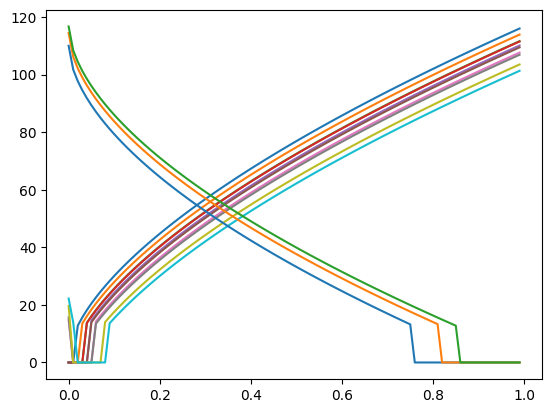

In [5]:
STEP = 0.01

def eval(bg):
    return [contrast(float(i), bg) for i in np.arange(0, 1, STEP)]

plots = [eval(i) for i in bg_y]

fig, ax = plt.subplots()
for i, v in zip(bg_y, plots):
    ax.plot(np.arange(0, 1, STEP), v, label=f"Y={i}")
plt.show()

Looking at the graph, it appears the optimal value of Y is approximately 0.35 and solely depends on Y=0.04 and Y=0.89. Plotting only those we get.

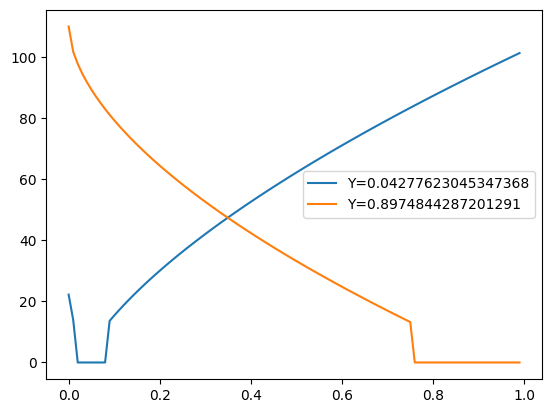

In [6]:
t1, t2 = bg_y[9], bg_y[10]

fig, ax = plt.subplots()
ax.plot(np.arange(0, 1, STEP), eval(t1), label=f"Y={t1}")
ax.plot(np.arange(0, 1, STEP), eval(t2), label=f"Y={t2}")
ax.legend()
plt.show()


We now use numerical methods to find that point. First define f(x), then the goal is to find the root. With some rearranging, this can be simplified too.

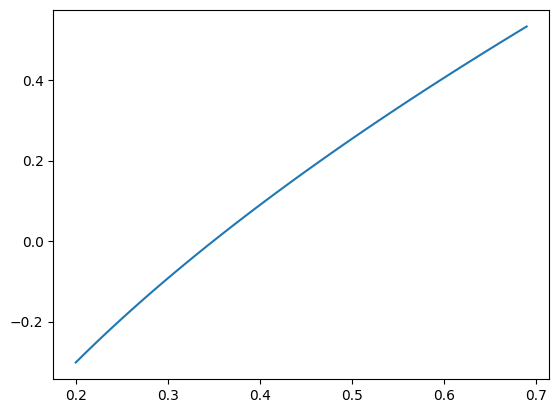

In [7]:
def foo(x):
    assert 0.2 <= x <= 0.7
    return x ** 0.62 + x ** 0.57 - (t1 ** 0.65 + t2 ** 0.56)

fig, ax = plt.subplots()
ax.plot(np.arange(0.2, 0.7, STEP), [foo(i) for i in np.arange(0.2, 0.7, STEP)])
plt.show()

Then solve numerically. This can use Newton's Method.

In [8]:
def dfoo(x):
    assert 0.2 <= x <= 0.7
    return 0.62 * x ** (0.62 - 1) + 0.57 * x ** (0.57 - 1)


def solve(x, steps):
    for i in range(steps):
        x = x - foo(x)/dfoo(x)
    return x

optimal_y = solve(0.35, 1000)
print(f"Solution = {repr(optimal_y)}")

Solution = 0.34937594007454498
